<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch02_Fancy_Tricks_with_Simple_Numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Fancy Tricks with Simple Numbers

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

Numeric data is already in a format that mathematical models can ingest directly. But "ingestible" does not mean "ready." This chapter covers the fundamental feature engineering techniques for numeric data: when and how to transform raw numbers into features that conform to the assumptions of your model. These techniques are universally applicable -- whenever raw data is converted to numeric features, some variant of these tools will be needed.

The chapter covers six major topics:

1. **Scalars, Vectors, and Spaces** -- the geometric foundation
2. **Dealing with Counts** -- binarization and binning
3. **Log and Power Transforms** -- taming heavy-tailed distributions
4. **Feature Scaling** -- min-max, standardization, $\ell_2$ normalization
5. **Interaction Features** -- capturing feature combinations
6. **Feature Selection** -- pruning to keep models lean

We use three real-world datasets throughout: the **Echo Nest Taste Profile** (Million Song Dataset), the **Yelp Academic Dataset**, and the **UCI Online News Popularity** dataset.

## Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy import stats
from sklearn import linear_model
from sklearn.model_selection import cross_val_score, train_test_split
import sklearn.preprocessing as preproc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"SciPy: {__import__('scipy').__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
SciPy: 1.16.3


All core libraries are loaded. We use scikit-learn for modeling and cross-validation, SciPy for the Box-Cox transform, and pandas for data manipulation. These are all pre-installed on Google Colab.

## Data Downloads

This notebook uses three datasets from the textbook. The cells below download them directly. The **Million Song** file is ~500 MB compressed -- it may take a few minutes. The **Yelp** dataset requires accepting Yelp's terms of service (we provide Kaggle and direct download options). The **UCI News** dataset downloads directly from the UCI repository.

In [ ]:
import os, zipfile, urllib.request

# --- 1) Million Song Dataset (Echo Nest Taste Profile subset) ---
if not os.path.exists('train_triplets.txt'):
    print("Downloading Million Song taste profile (~500 MB compressed)...")
    url = 'http://millionsongdataset.com/sites/default/files/challenge/train_triplets.txt.zip'
    urllib.request.urlretrieve(url, 'train_triplets.txt.zip')
    with zipfile.ZipFile('train_triplets.txt.zip', 'r') as z:
        z.extractall('.')
    print("Done.")
else:
    print("train_triplets.txt already exists.")

# --- 2) Yelp Academic Dataset ---
# The Yelp dataset requires their terms of service.
# Option A (Kaggle -- recommended):
!pip install -q kaggle
#   # Upload your kaggle.json, then:
!kaggle datasets download -d yelp-dataset/yelp-dataset \
     -f yelp_academic_dataset_business.json
!unzip -o yelp_academic_dataset_business.json.zip
# Option B: Download from https://www.yelp.com/dataset and upload the business JSON.

if not os.path.exists('yelp_academic_dataset_business.json'):
    print("\nYelp dataset not found. To get it, uncomment Option A above")
    print("or upload yelp_academic_dataset_business.json manually.")
else:
    print("yelp_academic_dataset_business.json found.")

# --- 3) UCI Online News Popularity ---
if not os.path.exists('OnlineNewsPopularity.csv'):
    print("\nDownloading UCI Online News Popularity dataset...")
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00332/OnlineNewsPopularity.zip'
    urllib.request.urlretrieve(url, 'OnlineNewsPopularity.zip')
    with zipfile.ZipFile('OnlineNewsPopularity.zip', 'r') as z:
        z.extractall('.')
    if os.path.exists('OnlineNewsPopularity/OnlineNewsPopularity.csv'):
        os.rename('OnlineNewsPopularity/OnlineNewsPopularity.csv',
                  'OnlineNewsPopularity.csv')
    print("Done.")
else:
    print("OnlineNewsPopularity.csv already exists.")

train_triplets.txt already exists.
Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 20.8M/20.8M [00:00<00:00, 57.1MB/s]

Archive:  yelp_academic_dataset_business.json.zip
  inflating: yelp_academic_dataset_business.json  
yelp_academic_dataset_business.json found.
OnlineNewsPopularity.csv already exists.


Once all three files are in the working directory, we are ready to proceed. If you skipped the Million Song download due to size constraints, you can still run everything from Section 2.2.2 onward (Yelp + News only).

## 2.1 Scalars, Vectors, and Spaces

Before proceeding to transformations, we need three foundational definitions:

A **scalar** is a single numeric feature value. A temperature reading, a price, a count -- each is a scalar.

A **vector** is an ordered list of scalars. If we measure three properties of a data point (e.g., height, weight, age), the result is a vector $\mathbf{x} = [x_1, x_2, x_3] \in \mathbb{R}^3$.

A **vector space** is the set of all possible vectors of a given dimensionality. Every data point lives as a point in this space, and the collection of all data points forms a **point cloud**.

In the vast majority of ML applications, the input to a model is a numeric vector. The entire book is about best-practice strategies for converting raw data into these vectors.

### Visualizing a Vector

A vector can be visualized as a point in space. For a two-dimensional vector $\mathbf{v} = [1, -1]$, the first component $v_1 = 1$ gives its position along dimension $d_1$, and $v_2 = -1$ gives its position along $d_2$.

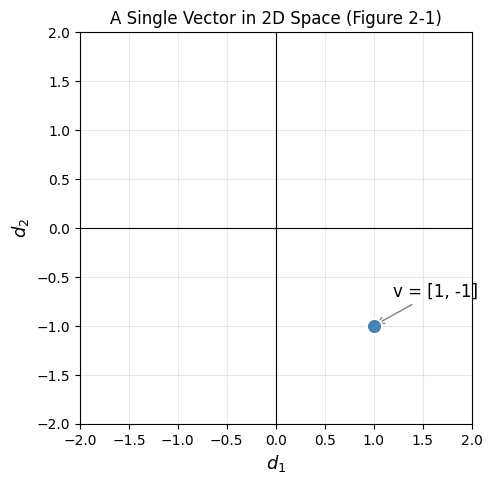

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter([1], [-1], s=120, color='steelblue', zorder=5, edgecolors='white', linewidths=1.5)
ax.annotate('v = [1, -1]', xy=(1, -1), xytext=(1.2, -0.7), fontsize=12,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('$d_1$', fontsize=13)
ax.set_ylabel('$d_2$', fontsize=13)
ax.set_title('A Single Vector in 2D Space (Figure 2-1)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

The plot shows the vector $\mathbf{v} = [1, -1]$ as a single point. In data terms, this might represent a listener's preferences: dimension $d_1$ could be their rating of "Blowin' in the Wind" (+1 = thumbs up) and $d_2$ their rating of "Poker Face" ($-1$ = thumbs down). Multiple listeners create a point cloud in this **feature space**.

### Feature Space vs. Data Space

The textbook introduces a crucial duality (Figure 2-2). Suppose we have a matrix where rows are listeners and columns are songs, with $+1$ for "like" and $-1$ for "dislike":

| | Blowin' in the Wind | Poker Face | Hallelujah | Creep | Roar |
|---|---|---|---|---|---|
| **Alice** | +1 | +1 | +1 | $-1$ | $-1$ |
| **Bob** | +1 | $-1$ | +1 | $-1$ | +1 |
| **Charlie** | $-1$ | $-1$ | $-1$ | +1 | $-1$ |
| **Donna** | $-1$ | +1 | $-1$ | $-1$ | +1 |

We can view this matrix two ways:

**Feature space** (left in Figure 2-2): Each **person** is a point, with song ratings as coordinates. Alice and Bob are points in "song space."

**Data space** (right in Figure 2-2): Each **song** is a point, with listener ratings as coordinates. "Poker Face" and "Creep" are points in "listener space."

This duality -- that rows and columns of the data matrix are interchangeable perspectives -- is a deep idea that recurs throughout ML, from collaborative filtering to SVD-based dimensionality reduction (Chapter 6).

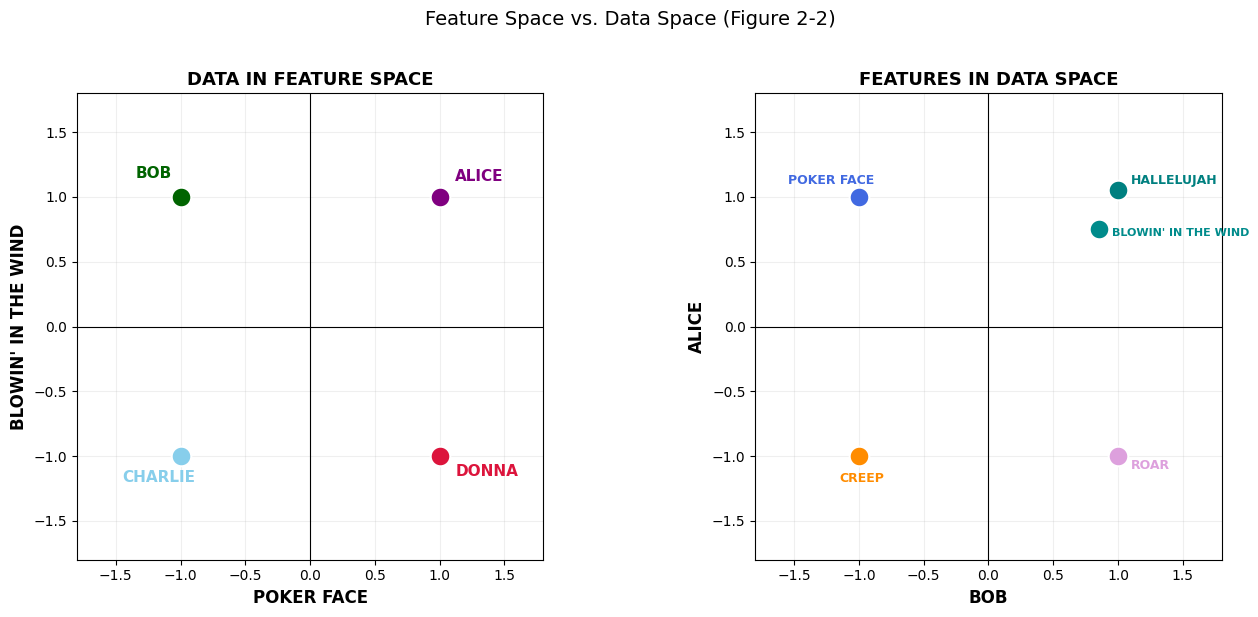

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Feature space (people as points, songs as axes)
# Using Blowin' in the Wind (y-axis) vs Poker Face (x-axis)
people = {
    'Bob':     ( -1,  1, 'darkgreen'),
    'Alice':   (  1,  1, 'purple'),
    'Charlie': ( -1, -1, 'skyblue'),
    'Donna':   (  1, -1, 'crimson'),
}
for name, (pf, bw, color) in people.items():
    ax1.scatter(pf, bw, s=200, color=color, zorder=5, edgecolors='white', linewidths=1.5)
    offset = {'Bob': (-0.35, 0.15), 'Alice': (0.12, 0.12),
              'Charlie': (-0.45, -0.2), 'Donna': (0.12, -0.15)}
    dx, dy = offset[name]
    ax1.text(pf + dx, bw + dy, name.upper(), fontsize=11, fontweight='bold', color=color)

ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlim(-1.8, 1.8); ax1.set_ylim(-1.8, 1.8)
ax1.set_xlabel('POKER FACE', fontsize=12, fontweight='bold')
ax1.set_ylabel("BLOWIN' IN THE WIND", fontsize=12, fontweight='bold')
ax1.set_title('DATA IN FEATURE SPACE', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.2); ax1.set_aspect('equal')

# RIGHT: Data space (songs as points, people as axes)
# Using Alice (y-axis) vs Bob (x-axis)
song_pos = {
    'Poker Face':          (-1,  1, 'royalblue'),
    'Hallelujah':          ( 1,  1.05, 'teal'),
    "Blowin' in the Wind": ( 0.85,  0.75, 'darkcyan'),
    'Creep':               (-1, -1, 'darkorange'),
    'Roar':                ( 1, -1, 'plum'),
}
for name, (bob, alice, color) in song_pos.items():
    ax2.scatter(bob, alice, s=200, color=color, zorder=5, edgecolors='white', linewidths=1.5)
    if name == 'Poker Face':
        ax2.text(bob - 0.55, alice + 0.1, name.upper(), fontsize=9, fontweight='bold', color=color)
    elif name == 'Hallelujah':
        ax2.text(bob + 0.1, alice + 0.05, name.upper(), fontsize=9, fontweight='bold', color=color)
    elif "Blowin" in name:
        ax2.text(bob + 0.1, alice - 0.05, name.upper(), fontsize=8, fontweight='bold', color=color)
    elif name == 'Creep':
        ax2.text(bob - 0.15, alice - 0.2, name.upper(), fontsize=9, fontweight='bold', color=color)
    else:
        ax2.text(bob + 0.1, alice - 0.1, name.upper(), fontsize=9, fontweight='bold', color=color)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlim(-1.8, 1.8); ax2.set_ylim(-1.8, 1.8)
ax2.set_xlabel('BOB', fontsize=12, fontweight='bold')
ax2.set_ylabel('ALICE', fontsize=12, fontweight='bold')
ax2.set_title('FEATURES IN DATA SPACE', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.2); ax2.set_aspect('equal')

fig.suptitle('Feature Space vs. Data Space (Figure 2-2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The two panels above recreate the textbook's Figure 2-2, illustrating the **duality between feature space and data space**.

**Left panel (Feature Space):** Each person is a point positioned by their song preferences. Bob (dark green) likes "Blowin' in the Wind" ($+1$) but dislikes "Poker Face" ($-1$), placing him in the upper-left quadrant. Alice (purple) likes both songs, landing in the upper-right. People with similar tastes cluster together -- this is the geometric basis of collaborative filtering.

**Right panel (Data Space):** Each song is a point positioned by how listeners rated it. "Poker Face" (blue) is liked by Alice ($+1$) but disliked by Bob ($-1$), placing it in the upper-left. "Hallelujah" and "Blowin' in the Wind" (both liked by Alice and Bob) cluster together in the upper-right -- they are "similar" songs in listener-preference space.

This duality is mathematically captured by the **transpose** of the data matrix. If $\mathbf{X}$ is the $n \times p$ matrix (listeners $\times$ songs), then $\mathbf{X}^T$ is the $p \times n$ matrix (songs $\times$ listeners). Both views contain exactly the same information, but enable different analyses: row-similarity finds similar users, column-similarity finds similar songs.

## 2.2 Dealing with Counts

Counts are among the most common numeric features: website visits, purchase quantities, review counts, listen counts, word frequencies. They share a universal property: **they can accumulate without bound**, and when data is produced at high volume, a few extreme values are almost guaranteed.

The first sanity check for any count feature is: **does the exact magnitude matter?** Three strategies, in order of increasing granularity:

1. **Binarize** -- convert to presence/absence ($0$ or $1$)
2. **Bin** -- group into coarse buckets (quantization)
3. **Keep raw** -- use the count as-is (only when the magnitude truly matters)

### 2.2.1 Binarization

The **Echo Nest Taste Profile** subset (the official user data for the Million Song Dataset) contains music listening histories for one million users:

- **48 million** (user, song, listen_count) triplets
- **1,019,318** unique users, **384,546** unique songs
- 99% of listen counts are $\leq 24$, but the maximum is **9,667**

The raw listen count is not a robust measure of user taste. Some users put songs on infinite loop; others savor favorites only on special occasions. We cannot say that someone who listens to a song 20 times likes it twice as much as someone who listens 10 times.

**Binarization** clips all counts $> 0$ to $1$: if the user listened at least once, we record a "like." This produces a simple, robust preference signal.

Mathematically, binarization is a step function:

$$\tilde{x} = \mathbf{1}[x > 0] = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x = 0 \end{cases}$$

In [ ]:
# Example 2-1: Load Million Song Dataset and binarize listen counts
listen_count = pd.read_csv('train_triplets.txt', header=None, delimiter='\t',
                           names=['user_id', 'song_id', 'count'])

print(f"=== Million Song Taste Profile ===")
print(f"Total triplets: {len(listen_count):,}")
print(f"Unique users:   {listen_count['user_id'].nunique():,}")
print(f"Unique songs:   {listen_count['song_id'].nunique():,}")
print(f"\nListen count statistics:")
print(listen_count['count'].describe())
print(f"\n99th percentile: {listen_count['count'].quantile(0.99):.0f}")
print(f"Max:             {listen_count['count'].max()}")

=== Million Song Taste Profile ===
Total triplets: 48,373,586
Unique users:   1,019,318
Unique songs:   384,546

Listen count statistics:
count    4.837359e+07
mean     2.866859e+00
std      6.437725e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      9.667000e+03
Name: count, dtype: float64

99th percentile: 24
Max:             9667


The statistics confirm the textbook's report: the vast majority of listen counts are small (99% $\leq 24$), but extreme values reach into the thousands. This heavy-tailed distribution is characteristic of user activity data -- a few power users dominate the count range.

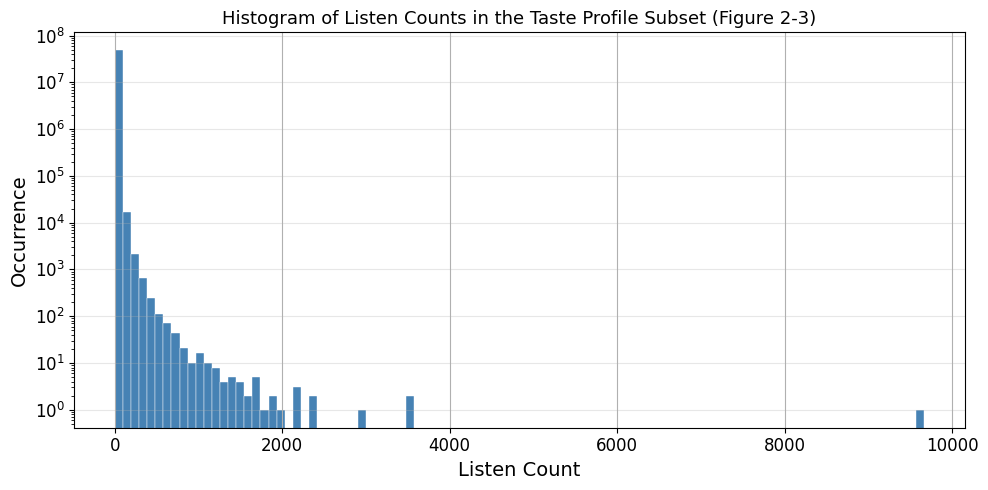

In [ ]:
# Figure 2-3: Histogram of listen counts (y-axis on log scale)
fig, ax = plt.subplots(figsize=(10, 5))
listen_count['count'].hist(ax=ax, bins=100, color='steelblue',
                           edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Listen Count', fontsize=14)
ax.set_ylabel('Occurrence', fontsize=14)
ax.set_title('Histogram of Listen Counts in the Taste Profile Subset (Figure 2-3)',
             fontsize=13)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The histogram peaks sharply near zero and drops off rapidly -- the y-axis must be log-scaled to make the tail visible at all. More than $10{,}000$ triplets have counts in the hundreds, with a few reaching the thousands. These extreme values would dominate any model trained on raw counts.

In [ ]:
# Example 2-1: Binarize
# The dataset only contains nonzero counts, so setting the entire column to 1
# is equivalent to binarization.
listen_count['count'] = 1
print("After binarization, all counts set to 1:")
print(listen_count.head(10))

After binarization, all counts set to 1:
                                    user_id             song_id  count
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOAKIMP12A8C130995      1
1  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOAPDEY12A81C210A9      1
2  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBBMDR12A8C13253B      1
3  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBFNSP12AF72A0E22      1
4  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBFOVM12A58A7D494      1
5  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBNZDC12A6D4FC103      1
6  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBSUJE12A6D4F8CF5      1
7  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBVFZR12A6D4F8AE3      1
8  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBXALG12A8C13C108      1
9  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBXHDL12A81C204C0      1


Since the Taste Profile only records nonzero listening events (if a user never listened to a song, there is no row), binarization is trivially implemented by setting the entire count column to 1. The binary target is a simple, robust measure of user preference -- the model no longer needs to predict the difference between a count of 20 and 500.

This is an example where we engineer the **target variable** rather than an input feature. Strictly speaking, the target is not a "feature," but the same transformation logic applies.

### 2.2.2 Quantization (Binning)

When binarization is too aggressive but raw counts span too many orders of magnitude, **binning** (quantization) provides a middle ground. It groups continuous values into discrete bins, reducing granularity while preserving ordinal information.

The textbook demonstrates binning on the **Yelp Reviews Dataset** (Round 6):

- **1,569,264** reviews across **61,184** businesses
- "Restaurants" (990,627 reviews) and "Nightlife" (210,028 reviews) are the most popular categories
- Review counts per business are heavily right-skewed

Two approaches: **fixed-width** bins and **adaptive (quantile)** bins.

#### Fixed-Width Binning

With fixed-width binning, each bin spans a specific numeric range. Bins can be **linearly spaced** (equal width) or **exponentially spaced** (width grows by powers of 10).

Linear binning divides by the bin width and takes the integer part:

$$\text{bin}(x) = \left\lfloor \frac{x}{w} \right\rfloor$$

Exponential binning applies the log first:

$$\text{bin}(x) = \left\lfloor \log_{10}(x) \right\rfloor$$

This maps $[1, 10) \to 0$, $[10, 100) \to 1$, $[100, 1{,}000) \to 2$, etc.

In [ ]:
# Example 2-3: Fixed-width binning (no external data needed)
np.random.seed(42)
small_counts = np.random.randint(0, 100, 20)
print("=== Fixed-Width Binning (Example 2-3) ===")
print(f"Random integers [0, 100): {small_counts}")
print(f"Bins (width=10):          {np.floor_divide(small_counts, 10)}")

large_counts = [296, 8286, 64011, 80, 3, 725, 867, 2215, 7689, 11495,
                91897, 44, 28, 7971, 926, 122, 22222]
print(f"\nLarge counts: {large_counts}")
print(f"Log10 bins:   {np.floor(np.log10(large_counts)).astype(int)}")
print("  (0=ones, 1=tens, 2=hundreds, 3=thousands, 4=ten-thousands)")

=== Fixed-Width Binning (Example 2-3) ===
Random integers [0, 100): [51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37]
Bins (width=10):          [5 9 1 7 6 2 8 8 7 7 8 9 2 0 2 5 0 8 2 3]

Large counts: [296, 8286, 64011, 80, 3, 725, 867, 2215, 7689, 11495, 91897, 44, 28, 7971, 926, 122, 22222]
Log10 bins:   [2 3 4 1 0 2 2 3 3 4 4 1 1 3 2 2 4]
  (0=ones, 1=tens, 2=hundreds, 3=thousands, 4=ten-thousands)


The first example maps 20 random integers in $[0, 100)$ to 10 bins of width 10 using integer division. A value of 64 maps to bin 6 (the 60s), a value of 7 maps to bin 0, and so on.

For the large counts spanning multiple orders of magnitude, linear bins would create thousands of mostly-empty bins. Instead, **exponential binning** via $\lfloor \log_{10}(x) \rfloor$ compresses the range: 296 (hundreds) maps to bin 2, 8,286 (thousands) to bin 3, and 91,897 (ten-thousands) to bin 4. Each order of magnitude gets equal representation.

The relationship between exponential binning and the log transform is no coincidence -- both use the logarithm to compress the high range and expand the low range. We will explore this connection in depth in Section 2.3.

#### Quantile Binning

Fixed-width bins can produce many **empty bins** when the data has gaps. **Quantile binning** solves this by adapting bin edges to the data distribution, ensuring each bin contains approximately the same number of data points.

**Quantiles** divide the data into equal portions: the **median** splits data in half, **quartiles** into quarters, **deciles** into tenths.

=== Yelp Business Dataset ===
Number of businesses: 150,346

Review count statistics:
count    150346.000000
mean         44.866561
std         121.120136
min           5.000000
25%           8.000000
50%          15.000000
75%          37.000000
max        7568.000000
Name: review_count, dtype: float64


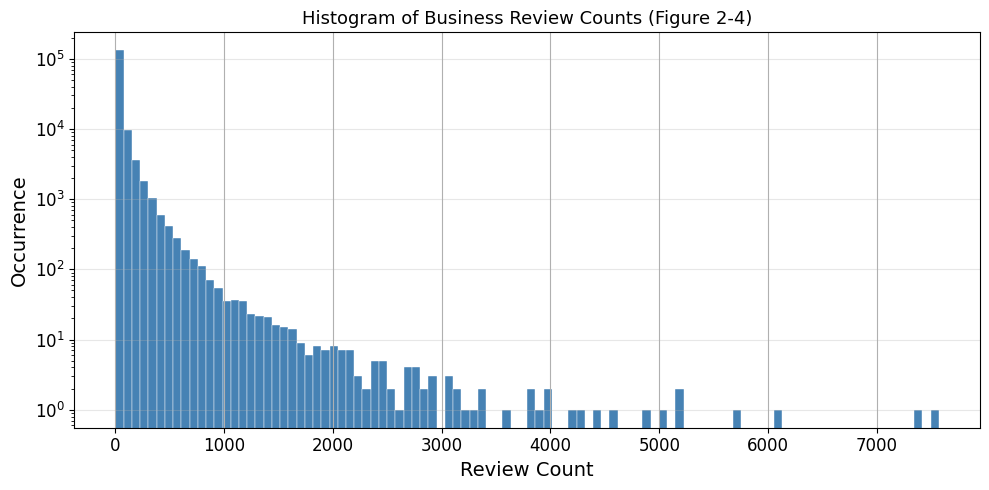

In [ ]:
# Example 2-2: Load Yelp business data
biz_file = open('yelp_academic_dataset_business.json')
biz_df = pd.DataFrame([json.loads(x) for x in biz_file.readlines()])
biz_file.close()

print(f"=== Yelp Business Dataset ===")
print(f"Number of businesses: {len(biz_df):,}")
print(f"\nReview count statistics:")
print(biz_df['review_count'].describe())

# Figure 2-4: Histogram of business review counts
fig, ax = plt.subplots(figsize=(10, 5))
biz_df['review_count'].hist(ax=ax, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Review Count', fontsize=14)
ax.set_ylabel('Occurrence', fontsize=14)
ax.set_title('Histogram of Business Review Counts (Figure 2-4)', fontsize=13)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The review count histogram shows the same heavy-tailed pattern as the listen counts: most businesses have a small number of reviews, but some have reviews in the thousands. The y-axis is log-scaled to make the tail visible. Raw counts that span several orders of magnitude are problematic for linear models and distance-based methods (like k-means), where a single large count can dominate the entire similarity measurement.

=== Deciles of Review Counts (Example 2-4) ===
0.1     6.0
0.2     7.0
0.3     9.0
0.4    11.0
0.5    15.0
0.6    20.0
0.7    30.0
0.8    48.0
0.9    97.0
Name: review_count, dtype: float64


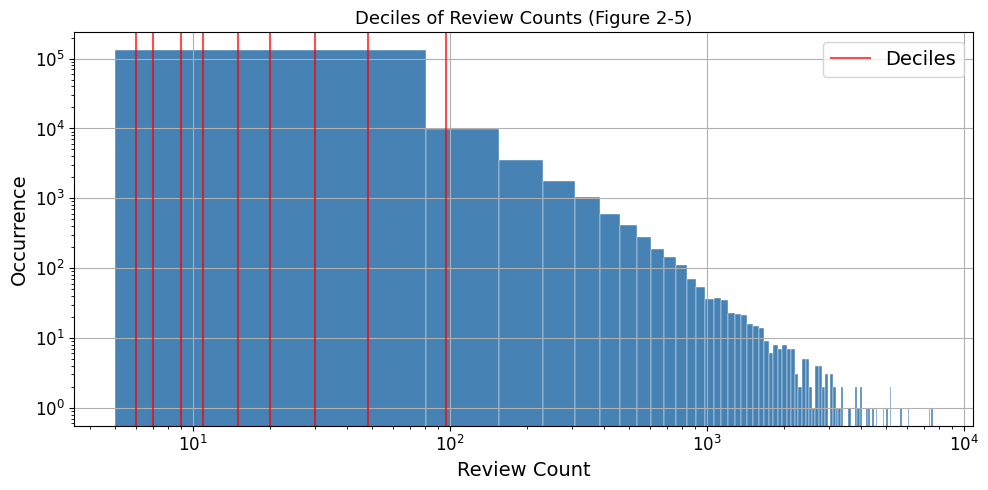

In [ ]:
# Example 2-4: Compute deciles of Yelp review counts
deciles = biz_df['review_count'].quantile([.1, .2, .3, .4, .5, .6, .7, .8, .9])
print("=== Deciles of Review Counts (Example 2-4) ===")
print(deciles)

# Figure 2-5: Histogram with decile overlay (log-log scale)
fig, ax = plt.subplots(figsize=(10, 5))
biz_df['review_count'].hist(ax=ax, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
for pos in deciles:
    handle = ax.axvline(pos, color='r', linewidth=1.5, alpha=0.7)
ax.legend([handle], ['Deciles'], fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Review Count', fontsize=14)
ax.set_ylabel('Occurrence', fontsize=14)
ax.set_title('Deciles of Review Counts (Figure 2-5)', fontsize=13)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

The deciles reveal the extreme skew of review counts. The textbook reports decile values of $3, 4, 5, 6, 8, 12, 17, 28, 58$ -- the bottom half of businesses have fewer than 10 reviews each. Meanwhile, the 90th percentile is at 58, meaning 10% of businesses have more than 58 reviews, with the tail stretching into the thousands.

The key advantage of **quantile binning**: every bin is equally populated, so the model can distinguish between bins with equal statistical power. With fixed-width bins on skewed data, most bins are empty and the model wastes capacity on unpopulated regions.

In [ ]:
# Example 2-5: Quantile binning with pd.qcut
large_counts = [296, 8286, 64011, 80, 3, 725, 867, 2215, 7689, 11495,
                91897, 44, 28, 7971, 926, 122, 22222]

# Map to quartiles
print("=== Quantile Binning (Example 2-5) ===")
print(f"Quartile bins: {list(pd.qcut(large_counts, 4, labels=False))}")

# Compute the quartile boundaries
large_counts_series = pd.Series(large_counts)
print(f"\nQuartile boundaries:")
print(large_counts_series.quantile([0.25, 0.5, 0.75]))

=== Quantile Binning (Example 2-5) ===
Quartile bins: [np.int64(1), np.int64(2), np.int64(3), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(3)]

Quartile boundaries:
0.25     122.0
0.50     926.0
0.75    8286.0
dtype: float64


The quartile boundaries at 122, 926, and 8,286 divide the 17 values into four groups of approximately equal size. Compare this with fixed-width bins of width 10,000: that would put 12 of the 17 values into the first bin and only 5 across all remaining bins. Quantile binning ensures each bin has roughly equal representation.

## 2.3 Log Transformation

The **log function** is one of the most important tools in the feature engineer's toolkit. It compresses the range of large numbers and expands the range of small numbers:

$$y = \log_{10}(x)$$

Key properties: $\log_{10}(1) = 0$, $\log_{10}(10) = 1$, $\log_{10}(100) = 2$, $\log_{10}(1{,}000) = 3$. Each additional order of magnitude in $x$ adds only 1 unit in $\log(x)$.

The log transform is a powerful tool for data with a **heavy-tailed distribution** -- one that places more probability mass in the tail than a Gaussian. It compresses the long tail in the high end into a shorter tail, and expands the low end into a longer head.

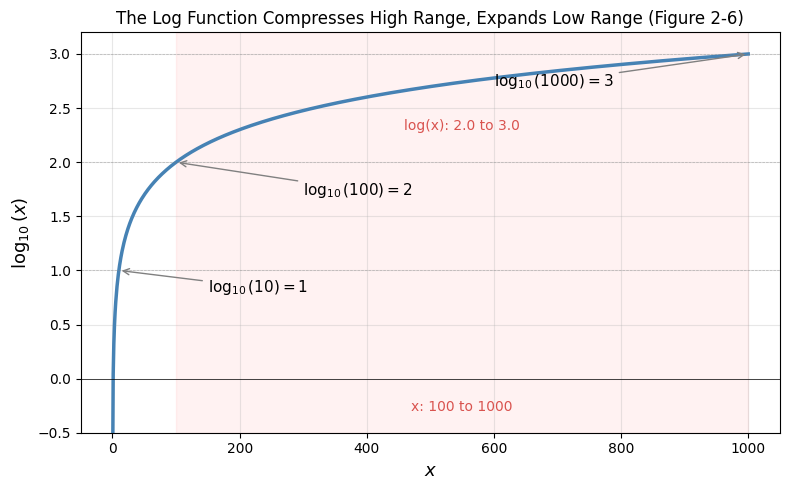

In [ ]:
# Figure 2-6: The log function
fig, ax = plt.subplots(figsize=(8, 5))
x = np.linspace(0.1, 1000, 1000)
ax.plot(x, np.log10(x), 'steelblue', linewidth=2.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(2, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(3, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

ax.annotate('$\log_{10}(10) = 1$', xy=(10, 1), xytext=(150, 0.8),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)
ax.annotate('$\log_{10}(100) = 2$', xy=(100, 2), xytext=(300, 1.7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)
ax.annotate('$\log_{10}(1000) = 3$', xy=(1000, 3), xytext=(600, 2.7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)

ax.fill_between([100, 1000], -0.5, 3.2, alpha=0.05, color='red')
ax.text(550, -0.3, 'x: 100 to 1000', ha='center', fontsize=10, color='#D9534F')
ax.text(550, 2.3, 'log(x): 2.0 to 3.0', ha='center', fontsize=10, color='#D9534F')

ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$\log_{10}(x)$', fontsize=13)
ax.set_title('The Log Function Compresses High Range, Expands Low Range (Figure 2-6)',
             fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 3.2)
plt.tight_layout()
plt.show()

The plot reveals the log function's compression: the horizontal range from 100 to 1,000 (a span of 900 units) compresses into just 2.0 to 3.0 on the y-axis (a span of 1 unit). Meanwhile, the range from 1 to 10 expands into 0 to 1 -- the same vertical span. This is exactly the behavior we need for heavy-tailed count data: **compress the extreme outliers and spread out the dense low-count region**.

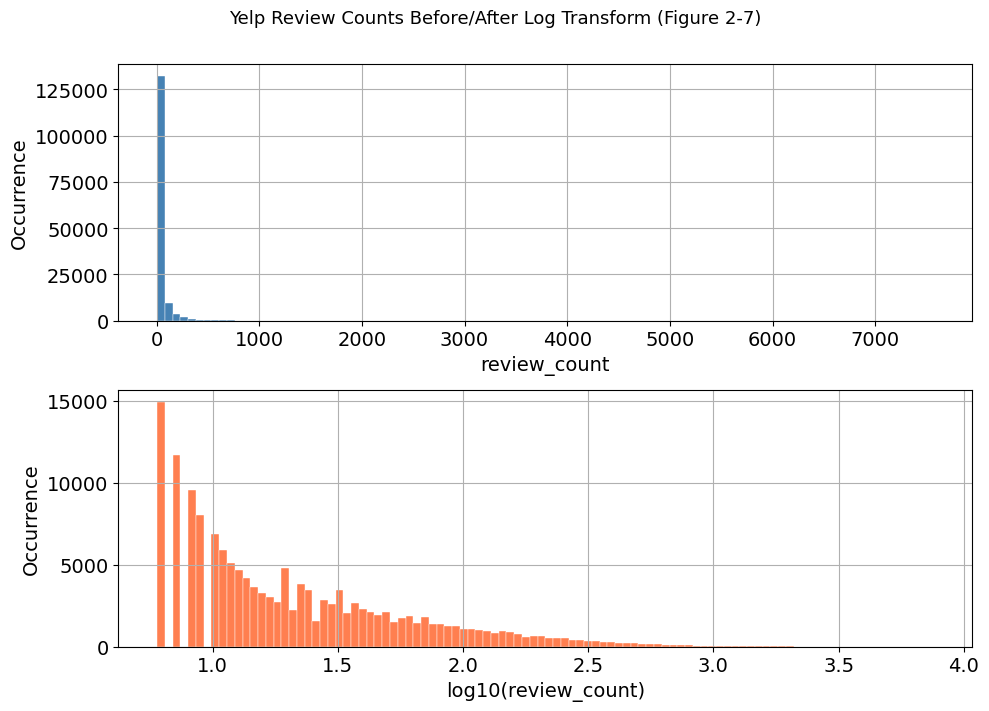

In [ ]:
# Figure 2-7: Yelp review counts before/after log transform
biz_df['log_review_count'] = np.log10(biz_df['review_count'] + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

biz_df['review_count'].hist(ax=ax1, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
ax1.tick_params(labelsize=14)
ax1.set_xlabel('review_count', fontsize=14)
ax1.set_ylabel('Occurrence', fontsize=14)

biz_df['log_review_count'].hist(ax=ax2, bins=100, color='coral',
                                 edgecolor='white', linewidth=0.3)
ax2.tick_params(labelsize=14)
ax2.set_xlabel('log10(review_count)', fontsize=14)
ax2.set_ylabel('Occurrence', fontsize=14)

fig.suptitle('Yelp Review Counts Before/After Log Transform (Figure 2-7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The transformation is dramatic. The original distribution (top) is extremely concentrated in the low-count region, with outliers stretching past 4,000. After the log transform (bottom), the data spreads out more evenly across the x-axis.

Note the `+ 1` in $\log_{10}(x + 1)$. This **offset** prevents the logarithm from producing $-\infty$ when $x = 0$. In the textbook's Yelp data, the minimum review count is 3, so the offset is technically unnecessary -- but it is a defensive programming habit that protects against zero-count edge cases.

### Log Transform on News Articles

The UCI Online News Popularity dataset provides another example: word counts in $39{,}797$ Mashable articles. Figure 2-8 compares the distribution before and after log transformation.

=== Online News Popularity Dataset ===
Shape: (39644, 61)


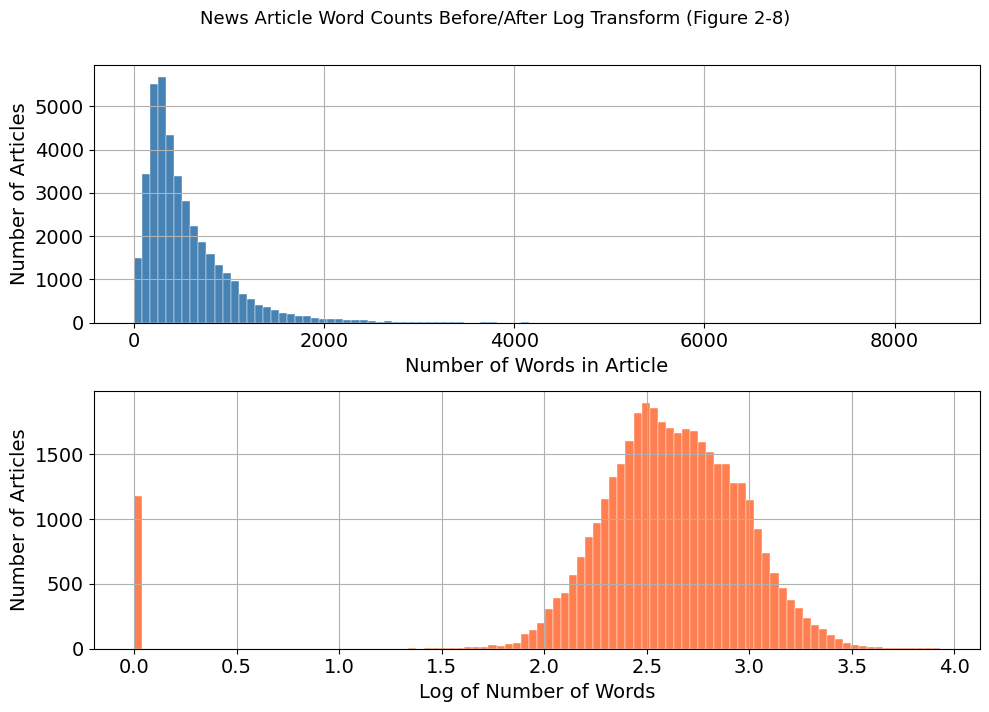

In [ ]:
# Load UCI Online News Popularity dataset
df = pd.read_csv('OnlineNewsPopularity.csv', delimiter=', ', engine='python')
df.columns = df.columns.str.strip()

print(f"=== Online News Popularity Dataset ===")
print(f"Shape: {df.shape}")

df['log_n_tokens_content'] = np.log10(df['n_tokens_content'] + 1)

# Figure 2-8: Word counts before/after log transform
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

df['n_tokens_content'].hist(ax=ax1, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
ax1.tick_params(labelsize=14)
ax1.set_xlabel('Number of Words in Article', fontsize=14)
ax1.set_ylabel('Number of Articles', fontsize=14)

df['log_n_tokens_content'].hist(ax=ax2, bins=100, color='coral',
                                 edgecolor='white', linewidth=0.3)
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Log of Number of Words', fontsize=14)
ax2.set_ylabel('Number of Articles', fontsize=14)

fig.suptitle('News Article Word Counts Before/After Log Transform (Figure 2-8)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

After the log transform, the distribution looks much more Gaussian, with the exception of a spike at zero (articles with no content). The increased bin spacing in the low range of the bottom plot is due to there being only 10 possible integer counts between 1 and 10. The log transform maps each of these to a distinct point in $[0, 1]$, but higher counts map to densely packed points.

### Log Transform in Action: Does It Help Prediction?

The textbook tests log-transformed features in a supervised learning setting using both datasets. Both use simple linear regression with 10-fold cross-validation, evaluated by $R^2$ score:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

$R^2 = 1$ is perfect prediction. $R^2 = 0$ is no better than the mean. $R^2 < 0$ means the model is *worse* than the mean.

In [ ]:
# Example 2-8: Yelp -- review count -> average star rating
m_orig = linear_model.LinearRegression()
scores_orig = cross_val_score(m_orig, biz_df[['review_count']],
                              biz_df['stars'], cv=10)

m_log = linear_model.LinearRegression()
scores_log = cross_val_score(m_log, biz_df[['log_review_count']],
                             biz_df['stars'], cv=10)

print("=== Yelp: Review Count -> Star Rating (Example 2-8) ===")
print("R-squared score without log transform: %0.5f (+/- %0.5f)"
      % (scores_orig.mean(), scores_orig.std() * 2))
print("R-squared score with log transform: %0.5f (+/- %0.5f)"
      % (scores_log.mean(), scores_log.std() * 2))

=== Yelp: Review Count -> Star Rating (Example 2-8) ===
R-squared score without log transform: 0.00354 (+/- 0.00148)
R-squared score with log transform: 0.00257 (+/- 0.00128)


The textbook reports: $R^2 \approx -0.037$ without log transform and $R^2 \approx -0.037$ with log transform. **Both models are equally bad.** Review count is simply a poor linear predictor of star rating -- neither raw count nor its logarithm provides useful signal for this particular task.

In [ ]:
# Example 2-9: News -- word count -> number of shares
m_orig = linear_model.LinearRegression()
scores_orig = cross_val_score(m_orig, df[['n_tokens_content']],
                              df['shares'], cv=10)

m_log = linear_model.LinearRegression()
scores_log = cross_val_score(m_log, df[['log_n_tokens_content']],
                             df['shares'], cv=10)

print("=== News: Word Count -> Shares (Example 2-9) ===")
print("R-squared score without log transform: %0.5f (+/- %0.5f)"
      % (scores_orig.mean(), scores_orig.std() * 2))
print("R-squared score with log transform: %0.5f (+/- %0.5f)"
      % (scores_log.mean(), scores_log.std() * 2))

=== News: Word Count -> Shares (Example 2-9) ===
R-squared score without log transform: -0.00242 (+/- 0.00509)
R-squared score with log transform: -0.00114 (+/- 0.00418)


The textbook reports: $R^2 \approx -0.00242$ without and $R^2 \approx -0.00114$ with log transform. The confidence intervals still overlap, but the model with the log-transformed feature is doing better. **Why does the log transform help here but not on Yelp?** The scatter plots below reveal the answer.

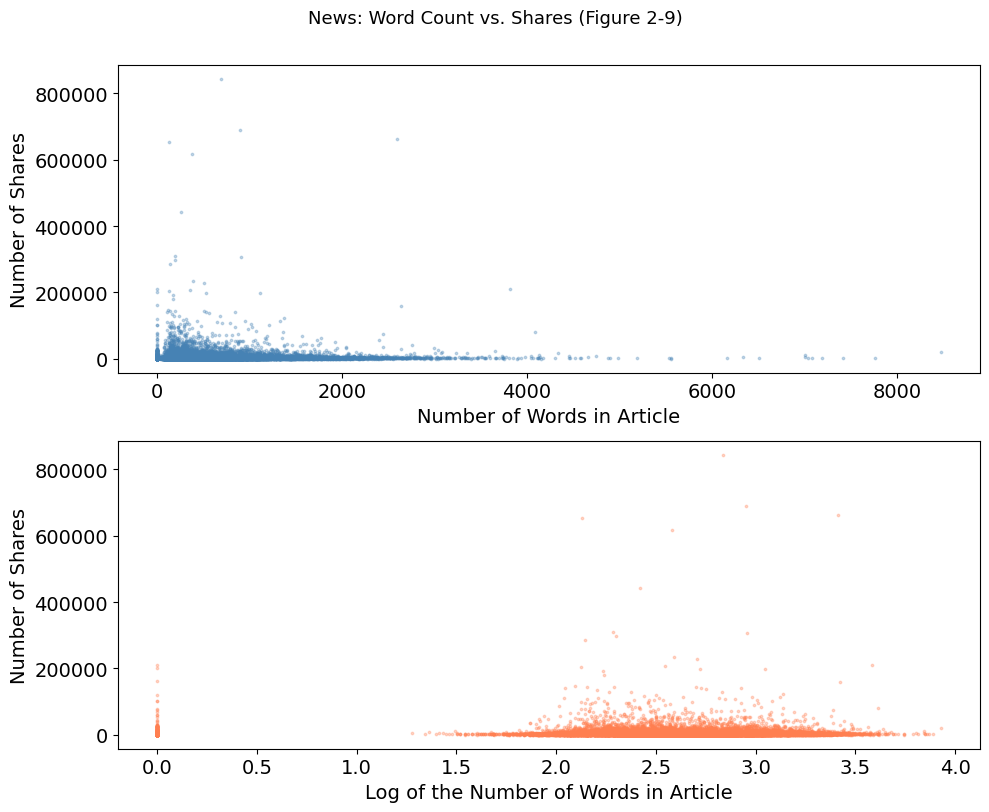

In [ ]:
# Example 2-10 / Figure 2-9: News scatter plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.scatter(df['n_tokens_content'], df['shares'], s=3, alpha=0.3,
            color='steelblue')
ax1.tick_params(labelsize=14)
ax1.set_xlabel('Number of Words in Article', fontsize=14)
ax1.set_ylabel('Number of Shares', fontsize=14)

ax2.scatter(df['log_n_tokens_content'], df['shares'], s=3, alpha=0.3,
            color='coral')
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Log of the Number of Words in Article', fontsize=14)
ax2.set_ylabel('Number of Shares', fontsize=14)

fig.suptitle('News: Word Count vs. Shares (Figure 2-9)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The log transform reshaped the x-axis, pulling articles with large outliers in the target ($> 200{,}000$ shares) further out toward the right. This gives the linear model more "breathing room" on the low end of the input feature space. Without the log transform (top), the model must fit very different target values under very small changes in the input.

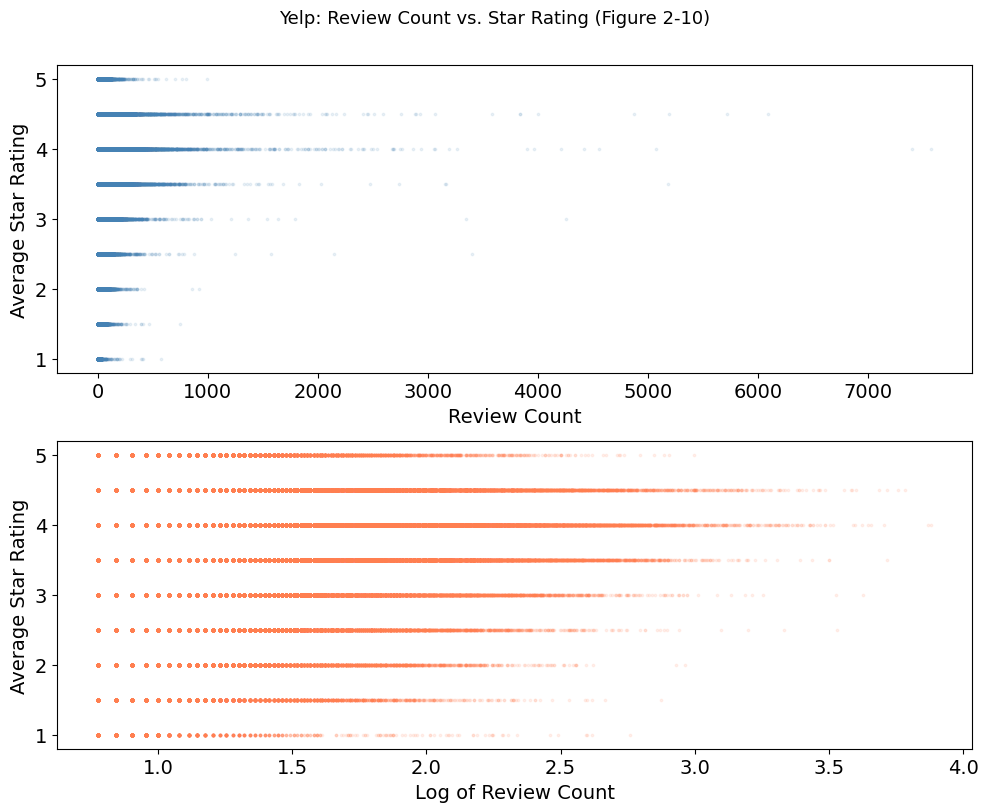

In [ ]:
# Example 2-11 / Figure 2-10: Yelp scatter plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.scatter(biz_df['review_count'], biz_df['stars'], s=3, alpha=0.1,
            color='steelblue')
ax1.tick_params(labelsize=14)
ax1.set_xlabel('Review Count', fontsize=14)
ax1.set_ylabel('Average Star Rating', fontsize=14)

ax2.scatter(biz_df['log_review_count'], biz_df['stars'], s=3, alpha=0.1,
            color='coral')
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Log of Review Count', fontsize=14)
ax2.set_ylabel('Average Star Rating', fontsize=14)

fig.suptitle('Yelp: Review Count vs. Star Rating (Figure 2-10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The Yelp scatter plots look very different from the news plots. The average star rating is discretized in half-star increments (1.0, 1.5, ..., 5.0), creating horizontal bands. There is no clear linear trend in either scale. Review count and its logarithm are both bad linear predictors of star rating.

**The lesson:** the log transform is not a universal fix. It helps when the feature-target relationship is approximately log-linear. Always **visualize the relationship** before and after transformation. As the textbook states:

> *"When building models, it is a good idea to visually inspect the relationships between input and output, and between different input features."*

## 2.4 Power Transforms: Generalization of the Log Transform

The log transform is one member of a family called **power transforms** -- variance-stabilizing transformations that decouple the variance of a distribution from its mean.

Consider the **Poisson distribution**, which models count data. Its variance equals its mean ($\text{Var}(X) = \lambda = \mathbb{E}[X]$). As the mean grows, the distribution spreads out proportionally.

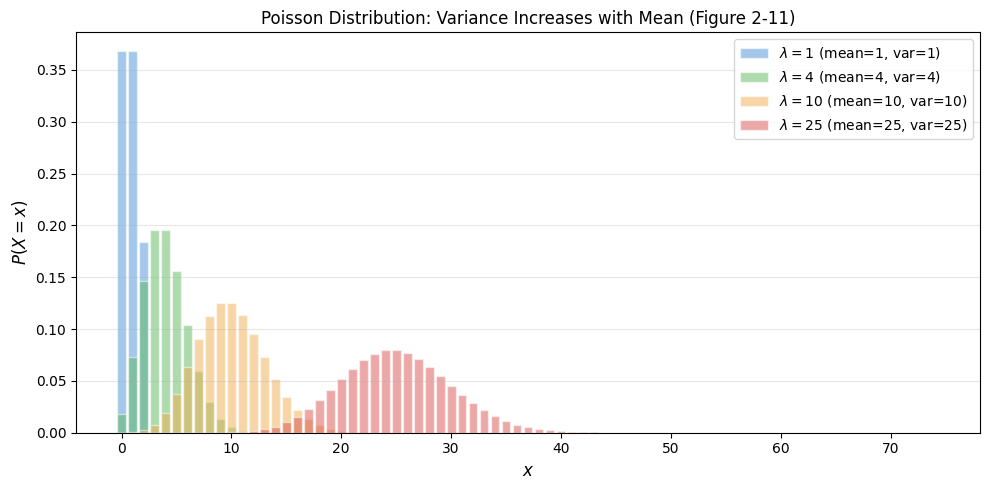

In [ ]:
# Figure 2-11: Poisson distributions with increasing lambda
fig, ax = plt.subplots(figsize=(10, 5))
lambdas = [1, 4, 10, 25]
colors = ['#4A90D9', '#5CB85C', '#F0AD4E', '#D9534F']

for lam, color in zip(lambdas, colors):
    x = np.arange(0, lam * 3)
    pmf = stats.poisson.pmf(x, lam)
    ax.bar(x, pmf, alpha=0.5, color=color, edgecolor='white',
           label=f'$\lambda = {lam}$ (mean={lam}, var={lam})', width=0.8)

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$P(X = x)$', fontsize=12)
ax.set_title('Poisson Distribution: Variance Increases with Mean (Figure 2-11)',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

At $\lambda = 1$ (blue), the distribution is tightly concentrated. At $\lambda = 25$ (red), the mass spreads across a much wider range. This means high-count features inherently have more variance -- a problem for models that assume homogeneous variance (like linear regression). Power transforms address this by compressing the high end.

### The Box-Cox Transform

A general family encompassing both the square root and log transforms:

$$\tilde{x} = \begin{cases} \frac{x^{\lambda} - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}$$

Setting $\lambda < 1$ compresses higher values; setting $\lambda > 1$ expands them. SciPy can find the **optimal** $\lambda$ via maximum likelihood.

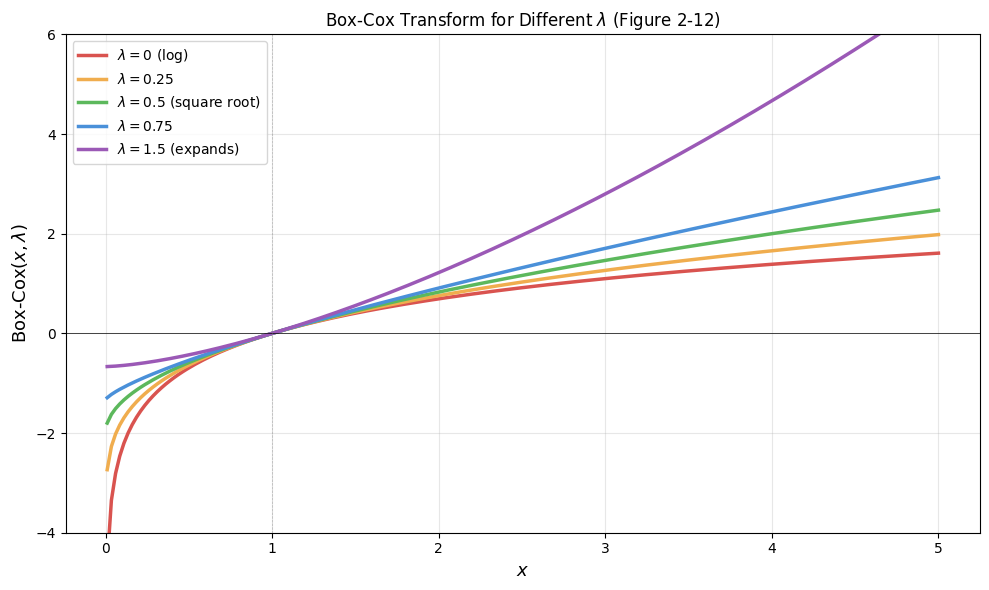

In [ ]:
# Figure 2-12: Box-Cox transforms for different lambda values
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0.01, 5, 200)

for lam, color, label in [(0, '#D9534F', '$\lambda = 0$ (log)'),
                           (0.25, '#F0AD4E', '$\lambda = 0.25$'),
                           (0.5, '#5CB85C', '$\lambda = 0.5$ (square root)'),
                           (0.75, '#4A90D9', '$\lambda = 0.75$'),
                           (1.5, '#9B59B6', '$\lambda = 1.5$ (expands)')]:
    y = np.log(x) if lam == 0 else (x**lam - 1) / lam
    ax.plot(x, y, color=color, linewidth=2.5, label=label)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('Box-Cox$(x, \lambda)$', fontsize=13)
ax.set_title('Box-Cox Transform for Different $\lambda$ (Figure 2-12)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-4, 6)
plt.tight_layout()
plt.show()

The Box-Cox family forms a continuum: $\lambda = 0$ (log) gives the strongest compression, $\lambda = 0.5$ (square root) gives moderate compression, and $\lambda = 1.5$ actually expands the high end. All curves pass through $(1, 0)$.

In [ ]:
# Example 2-12: Box-Cox on Yelp review counts
print(f"Min review count: {biz_df['review_count'].min()}")

# Log transform (lambda=0)
rc_log = stats.boxcox(biz_df['review_count'].values.astype(float), lmbda=0)

# Optimal Box-Cox (SciPy finds best lambda via max likelihood)
rc_bc, bc_params = stats.boxcox(biz_df['review_count'].values.astype(float))
print(f"Optimal Box-Cox lambda: {bc_params:.10f}")

biz_df['rc_log'] = rc_log
biz_df['rc_bc'] = rc_bc

Min review count: 5
Optimal Box-Cox lambda: -0.4001085694


The textbook reports an optimal $\lambda \approx -0.4107$. A negative $\lambda$ indicates that the data needs even stronger compression than the log transform ($\lambda = 0$) to approach Gaussianity.

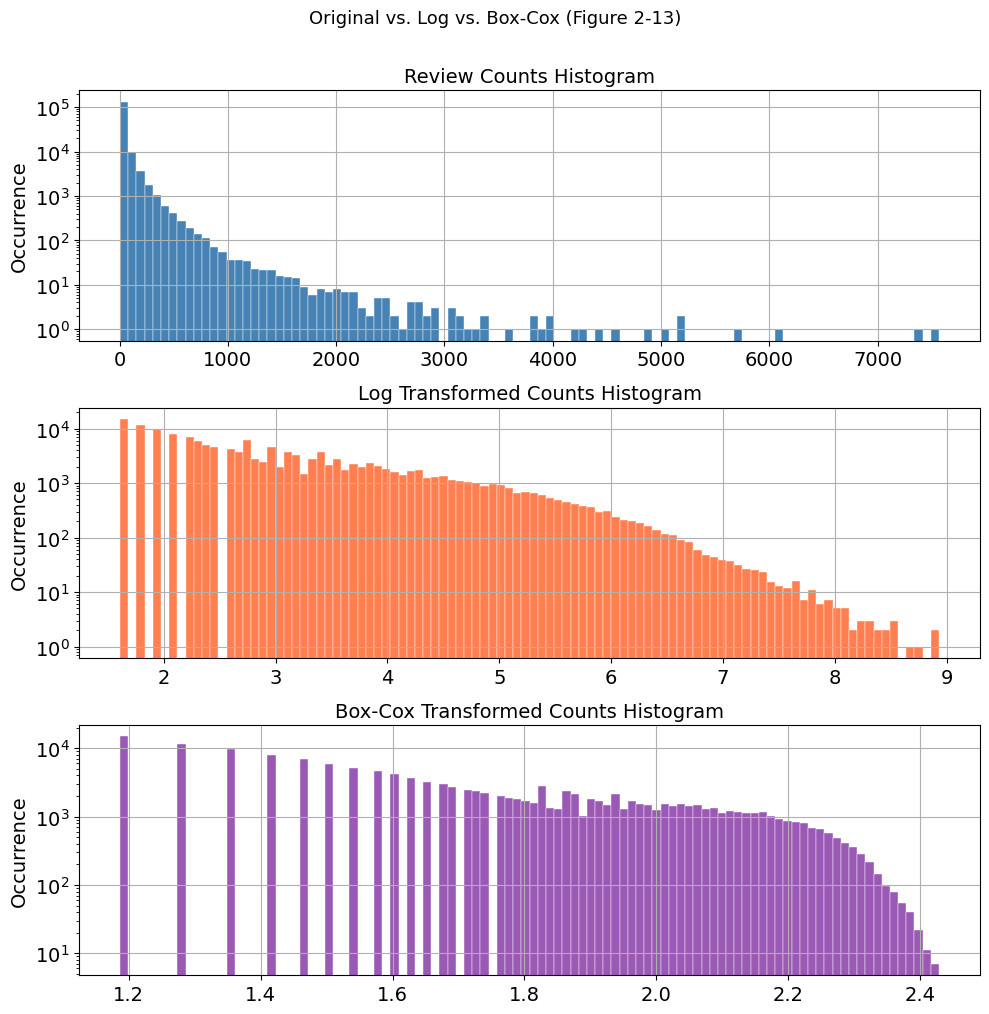

In [ ]:
# Example 2-13 / Figure 2-13: Compare original, log, Box-Cox histograms
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

biz_df['review_count'].hist(ax=ax1, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
ax1.set_yscale('log')
ax1.tick_params(labelsize=14)
ax1.set_title('Review Counts Histogram', fontsize=14)
ax1.set_xlabel('')
ax1.set_ylabel('Occurrence', fontsize=14)

biz_df['rc_log'].hist(ax=ax2, bins=100, color='coral',
                       edgecolor='white', linewidth=0.3)
ax2.set_yscale('log')
ax2.tick_params(labelsize=14)
ax2.set_title('Log Transformed Counts Histogram', fontsize=14)
ax2.set_xlabel('')
ax2.set_ylabel('Occurrence', fontsize=14)

biz_df['rc_bc'].hist(ax=ax3, bins=100, color='#9B59B6',
                      edgecolor='white', linewidth=0.3)
ax3.set_yscale('log')
ax3.tick_params(labelsize=14)
ax3.set_title('Box-Cox Transformed Counts Histogram', fontsize=14)
ax3.set_xlabel('')
ax3.set_ylabel('Occurrence', fontsize=14)

fig.suptitle('Original vs. Log vs. Box-Cox (Figure 2-13)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The comparison across three panels shows progressive normalization: the original data (top) is extremely skewed; the log transform (middle) improves symmetry substantially; the optimal Box-Cox (bottom) fine-tunes the compression to best match a Gaussian shape.

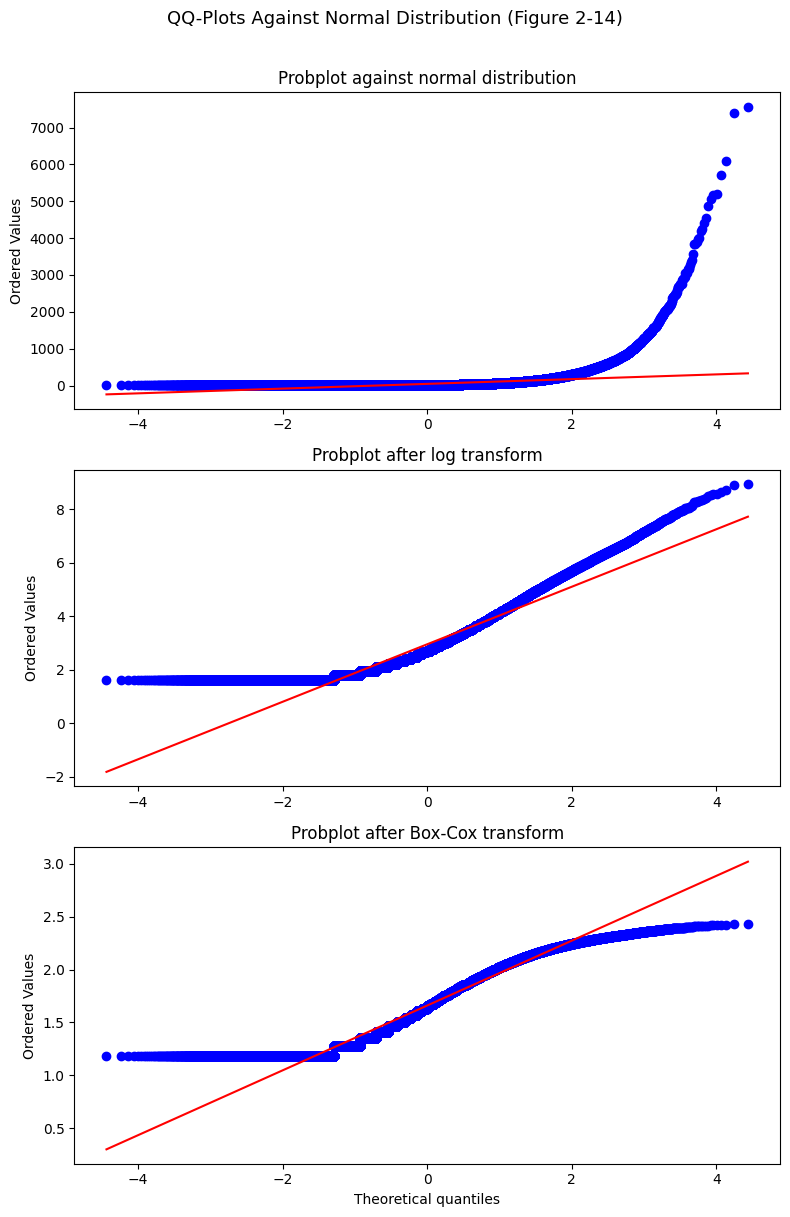

In [ ]:
# Example 2-14 / Figure 2-14: Probability plots (QQ-plots) against normal
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

stats.probplot(biz_df['review_count'].values, dist=stats.norm, plot=ax1)
ax1.set_xlabel('')
ax1.set_title('Probplot against normal distribution')

stats.probplot(biz_df['rc_log'].values, dist=stats.norm, plot=ax2)
ax2.set_xlabel('')
ax2.set_title('Probplot after log transform')

stats.probplot(biz_df['rc_bc'].values, dist=stats.norm, plot=ax3)
ax3.set_xlabel('Theoretical quantiles')
ax3.set_title('Probplot after Box-Cox transform')

fig.suptitle('QQ-Plots Against Normal Distribution (Figure 2-14)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Probability plots** (QQ-plots) provide the clearest diagnostic for normality. If the data were perfectly Gaussian, all points would fall on the red diagonal line.

**Top (Original):** The observed values shoot dramatically above the line -- the heavy tail extends to thousands while the normal distribution expects values of at most $\sim 4$ standard deviations.

**Middle (Log):** The fit improves substantially. The middle aligns well, though the right tail still curves slightly upward.

**Bottom (Box-Cox):** The optimal Box-Cox provides the closest fit to normality. The tail is flattened further, falling closer to the diagonal.

In practice, either transform is usually sufficient. The Box-Cox offers marginal improvement at the cost of an additional hyperparameter ($\lambda$) and the requirement that input values are strictly positive.

## 2.5 Feature Scaling (Normalization)

Models that are smooth functions of the input -- linear regression, logistic regression, SVMs with RBF kernels, k-means clustering, neural networks -- are **sensitive to feature scale**. If one feature ranges from 0 to 1 and another from 0 to $1{,}000{,}000$, the large-scale feature will dominate.

**Tree-based models** (decision trees, random forests, gradient boosting) are **not sensitive to scale** because they make decisions based on threshold comparisons, not distances.

### Min-Max Scaling

$$\tilde{x} = \frac{x - \min(x)}{\max(x) - \min(x)}$$

Squeezes all values into $[0, 1]$. Distribution shape is preserved.

### Standardization (Variance Scaling)

$$\tilde{x} = \frac{x - \text{mean}(x)}{\sqrt{\text{Var}(x)}}$$

Centers to mean zero, scales to unit variance. If originally Gaussian, the result is $\mathcal{N}(0, 1)$.

### $\ell_2$ Normalization

$$\tilde{x} = \frac{x}{\|\mathbf{x}\|_2} \quad \text{where} \quad \|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}$$

After normalization, the feature column has unit norm.

**Warning:** Do not apply min-max scaling or standardization to **sparse features** (like bag-of-words). Both subtract a value from every element, turning sparse vectors **dense** -- potentially exploding memory from megabytes to gigabytes.

=== Feature Scaling (Example 2-15) ===
Original:       [ 219.  255.  211.  531. 1072.]
Min-max:        [0.025844 0.030092 0.0249   0.062662 0.126505]
Standardized:   [-0.69521  -0.618794 -0.712192 -0.032933  1.115439]
L2-normalized:  [0.00152439 0.00177498 0.00146871 0.00369613 0.00746187]


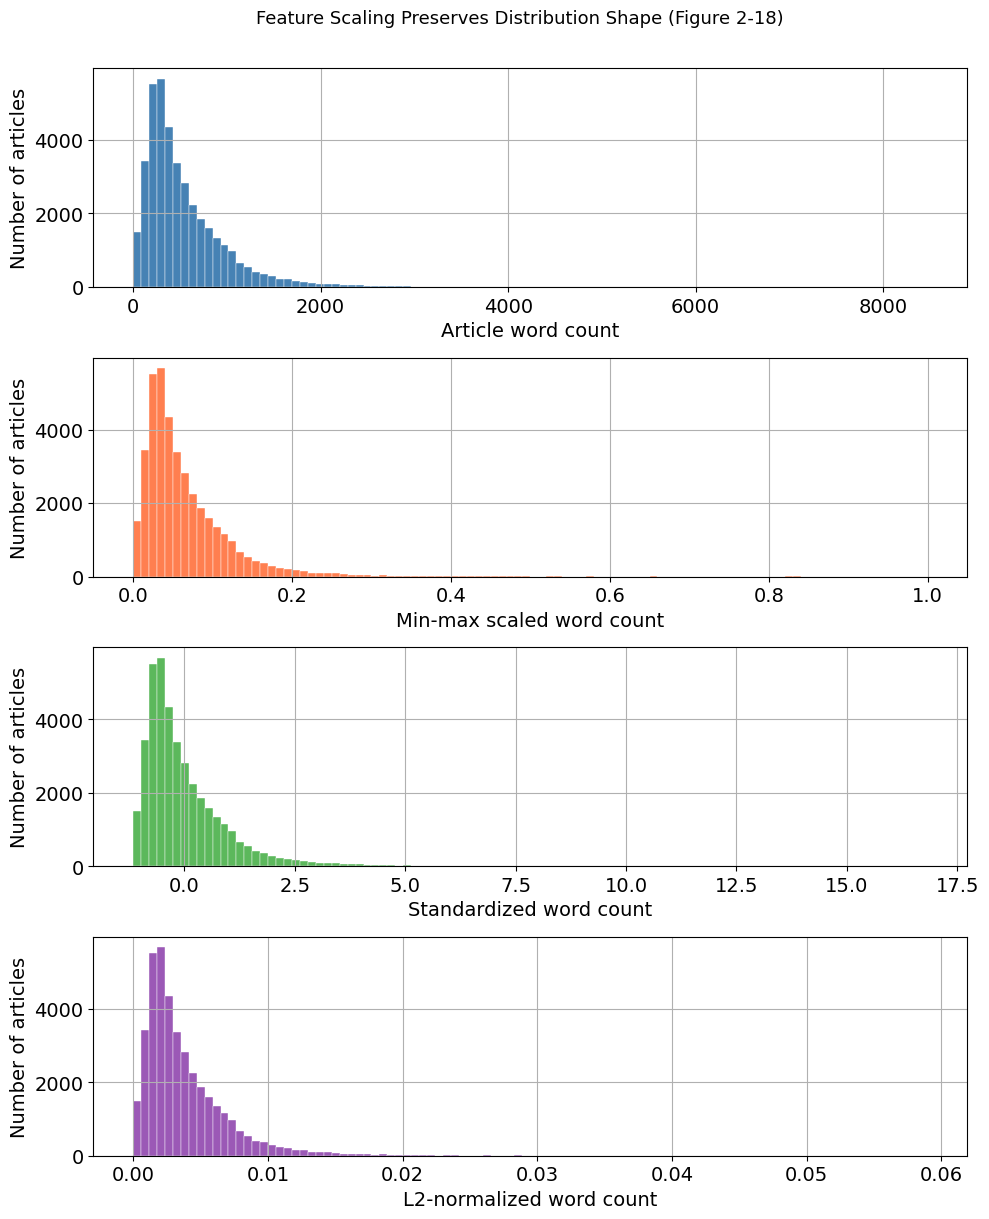

In [ ]:
# Examples 2-15, 2-16 / Figure 2-18: Feature scaling on news word counts
feature_col = df[['n_tokens_content']]

df['minmax'] = preproc.minmax_scale(feature_col)
df['standardized'] = preproc.StandardScaler().fit_transform(feature_col)
df['l2_normalized'] = preproc.normalize(feature_col, axis=0)

print("=== Feature Scaling (Example 2-15) ===")
print(f"Original:       {df['n_tokens_content'].values[:5]}")
print(f"Min-max:        {df['minmax'].values[:5].round(6)}")
print(f"Standardized:   {df['standardized'].values[:5].round(6)}")
print(f"L2-normalized:  {df['l2_normalized'].values[:5].round(8)}")

# Figure 2-18: Scaling preserves distribution shape
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 12))
fig.tight_layout(pad=3.0)

df['n_tokens_content'].hist(ax=ax1, bins=100, color='steelblue',
                             edgecolor='white', linewidth=0.3)
ax1.tick_params(labelsize=14)
ax1.set_xlabel('Article word count', fontsize=14)
ax1.set_ylabel('Number of articles', fontsize=14)

df['minmax'].hist(ax=ax2, bins=100, color='coral',
                   edgecolor='white', linewidth=0.3)
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Min-max scaled word count', fontsize=14)
ax2.set_ylabel('Number of articles', fontsize=14)

df['standardized'].hist(ax=ax3, bins=100, color='#5CB85C',
                         edgecolor='white', linewidth=0.3)
ax3.tick_params(labelsize=14)
ax3.set_xlabel('Standardized word count', fontsize=14)
ax3.set_ylabel('Number of articles', fontsize=14)

df['l2_normalized'].hist(ax=ax4, bins=100, color='#9B59B6',
                          edgecolor='white', linewidth=0.3)
ax4.tick_params(labelsize=14)
ax4.set_xlabel('L2-normalized word count', fontsize=14)
ax4.set_ylabel('Number of articles', fontsize=14)

fig.suptitle('Feature Scaling Preserves Distribution Shape (Figure 2-18)',
             fontsize=13, y=1.01)
plt.show()

A critical observation: **all four histograms have the same shape**. Feature scaling only changes the x-axis scale -- it does not reshape the distribution. This is the fundamental difference between scaling and transformations like log or Box-Cox:

| Operation | Changes Shape? | Changes Scale? | Use Case |
|---|---|---|---|
| **Log / Box-Cox** | Yes | Yes | Tame heavy tails, approach Gaussianity |
| **Feature Scaling** | No | Yes | Equalize feature ranges for distance-based models |

Mathematically, all three scaling methods are **affine transformations** $\tilde{x} = ax + b$, which preserve distribution shape.

## 2.6 Interaction Features

A simple linear model uses a weighted sum of individual features:

$$y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n$$

This assumes features contribute **independently**. **Interaction features** capture dependencies by including pairwise products:

$$y = \underbrace{w_1 x_1 + \cdots + w_n x_n}_{\text{main effects}} + \underbrace{w_{1,1} x_1^2 + w_{1,2} x_1 x_2 + w_{1,3} x_1 x_3 + \cdots}_{\text{interactions and squared terms}}$$

For binary features, the product $x_i \cdot x_j$ is a logical AND. With $n$ original features, pairwise interactions create $\frac{n(n+1)}{2}$ new features -- complexity grows from $O(n)$ to $O(n^2)$.

In [ ]:
# Example 2-17: Interaction features on UCI News dataset
features = ['n_tokens_title', 'n_tokens_content',
            'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
            'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
            'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
            'data_channel_is_entertainment', 'data_channel_is_bus',
            'data_channel_is_socmed', 'data_channel_is_tech',
            'data_channel_is_world']

X = df[features]
y = df['shares']

# Create pairwise interaction features, skipping the constant bias term
X2 = PolynomialFeatures(include_bias=False).fit_transform(X)
print(f"Singleton features shape: {X.shape}")
print(f"With interactions shape:  {X2.shape}")

# Train/test split and evaluation
X1_train, X1_test, X2_train, X2_test, y_train, y_test = \
    train_test_split(X, X2, y, test_size=0.3, random_state=123)

def evaluate_feature(X_train, X_test, y_train, y_test):
    model = linear_model.LinearRegression().fit(X_train, y_train)
    return model.score(X_test, y_test)

r1 = evaluate_feature(X1_train, X1_test, y_train, y_test)
r2 = evaluate_feature(X2_train, X2_test, y_train, y_test)

print(f"\nR-squared score with singleton features: {r1:.5f}")
print(f"R-squared score with pairwise features:  {r2:.10f}")

Singleton features shape: (39644, 17)
With interactions shape:  (39644, 170)

R-squared score with singleton features: 0.00924
R-squared score with pairwise features:  0.0111475204


Starting from 17 content-based features, `PolynomialFeatures` expands to 170: the original 17, plus 17 squared terms, plus $\binom{17}{2} = 136$ pairwise products. The textbook reports $R^2 \approx 0.00924$ for singletons and $R^2 \approx 0.01133$ for interactions -- a modest improvement showing that feature combinations carry information that individual features do not.

The computational tradeoff is significant: for 10,000 features the interaction set would contain over 50 million features. This is where **feature selection** becomes essential.

## 2.7 Feature Selection

When the feature space grows large, **feature selection** prunes non-useful features to produce a simpler, faster model. Three major categories:

**Filtering:** Preprocess features before training. Compute correlation or mutual information with the target, remove low-scoring features. Fast but ignores feature interactions.

**Wrapper methods:** Iteratively try feature subsets and evaluate the model each time (forward selection, backward elimination, recursive feature elimination). Thorough but expensive -- can require $2^n$ evaluations.

**Embedded methods:** Feature selection built into training. The $\ell_1$ (Lasso) regularizer adds a penalty $\lambda \sum |w_j|$ that drives unimportant weights to exactly zero. Decision trees inherently select features at each split. Embedded methods strike the best balance between cost and quality.

$$\min_{\mathbf{w}} \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}^T\mathbf{x}_i)^2 + \lambda \|\mathbf{w}\|_1$$

The $\|\mathbf{w}\|_1 = \sum_j |w_j|$ term is the **sparsity constraint** -- it penalizes the model for using many features.

In [ ]:
# Lasso (L1) feature selection on the interaction features
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100, max_iter=10000, random_state=42)
lasso.fit(X2_train, y_train)

n_nonzero = np.sum(lasso.coef_ != 0)
r_lasso = lasso.score(X2_test, y_test)

print(f"=== Lasso (L1) Feature Selection ===")
print(f"Total interaction features: {X2.shape[1]}")
print(f"Non-zero coefficients:     {n_nonzero}")
print(f"Features eliminated:       {X2.shape[1] - n_nonzero}")
print(f"R-squared on test set:     {r_lasso:.5f}")
print(f"\nLasso selected {n_nonzero}/{X2.shape[1]} features "
      f"({n_nonzero/X2.shape[1]:.1%})")

=== Lasso (L1) Feature Selection ===
Total interaction features: 170
Non-zero coefficients:     67
Features eliminated:       103
R-squared on test set:     0.01074

Lasso selected 67/170 features (39.4%)


From 170 interaction features, the Lasso selects only a fraction -- the model identifies which features and interactions carry predictive signal and discards the rest. The resulting model is sparser, faster to score, and easier to interpret, with comparable performance due to reduced overfitting.

This pattern -- generate a rich set of candidate features, then let regularization prune -- is one of the most practical workflows in applied ML. It allows the data to decide which features matter.

## 2.8 Key Takeaways

**Scalars, Vectors, and Spaces:** All data is ultimately represented as numeric vectors. The same data matrix can be viewed in feature space (data points as vectors of features) or data space (features as vectors of data points) -- a duality exploited by many ML algorithms.

**Dealing with Counts:** Raw counts that span orders of magnitude are problematic for most models. Three strategies: **binarize** (presence/absence), **bin** (fixed-width or quantile), or **transform** (log/power). Always check the scale first.

**Log and Power Transforms:** The log transform compresses the high end and expands the low end of heavy-tailed distributions, bringing them closer to Gaussian. The Box-Cox transform generalizes this with a tunable parameter $\lambda$. These change the **shape** of the distribution, unlike feature scaling.

**Feature Scaling:** Min-max scaling, standardization, and $\ell_2$ normalization change the **scale** but not the **shape** of distributions. Essential for distance-based and gradient-based models; irrelevant for tree-based models. Never "center" sparse data.

**Interaction Features:** Products of feature pairs capture dependencies that individual features cannot. They expand $n$ features to $O(n^2)$, making feature selection necessary.

**Feature Selection:** Three approaches with different cost-quality tradeoffs: filtering (cheap, ignores interactions), wrapper methods (thorough, expensive), and embedded methods ($\ell_1$ regularization, tree-based importance -- the practical sweet spot).

---

*In Chapter 3, we move from numbers to text -- a far more complex data type that requires its own specialized feature engineering techniques.*